In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")


In [23]:
df = pd.read_csv(
    "/content/API_SP.POP.TOTL_DS2_en_csv_v2_346039.csv",
    skiprows=4
)

In [24]:
print(df.shape)
print(df.columns.tolist())
print(df.head())

(266, 71)
['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code', '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968', '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025', 'Unnamed: 70']
                  Country Name Country Code     Indicator Name Indicator Code  \
0                        Aruba          ABW  Population, total    SP.POP.TOTL   
1  Africa Eastern and Southern          AFE  Population, total    SP.POP.TOTL   
2                  Afghanistan          AFG  Population, total    SP.POP.TOTL   
3   Africa Western and Central          AFW  Populatio

In [25]:
latest_year = df.columns[-1]

In [26]:
year_cols = [col for col in df.columns if col.isdigit()]

for year in reversed(year_cols):
    if df[year].notna().sum() > 0:
        latest_year = year
        break

print("Latest Year:", latest_year)

Latest Year: 2024


In [27]:
population = df[['Country Name', latest_year]]

In [28]:
population = population.dropna()

In [29]:
print(population.shape)
print(population.head())

(265, 2)
                  Country Name         2024
0                        Aruba     107995.0
1  Africa Eastern and Southern  769280888.0
2                  Afghanistan   42647492.0
3   Africa Western and Central  521764076.0
4                       Angola   37885849.0


In [30]:
print(population[latest_year].describe())

count    2.650000e+02
mean     3.318713e+08
std      1.021698e+09
min      9.646000e+03
25%      1.824359e+06
50%      1.090503e+07
75%      6.855165e+07
max      8.141809e+09
Name: 2024, dtype: float64


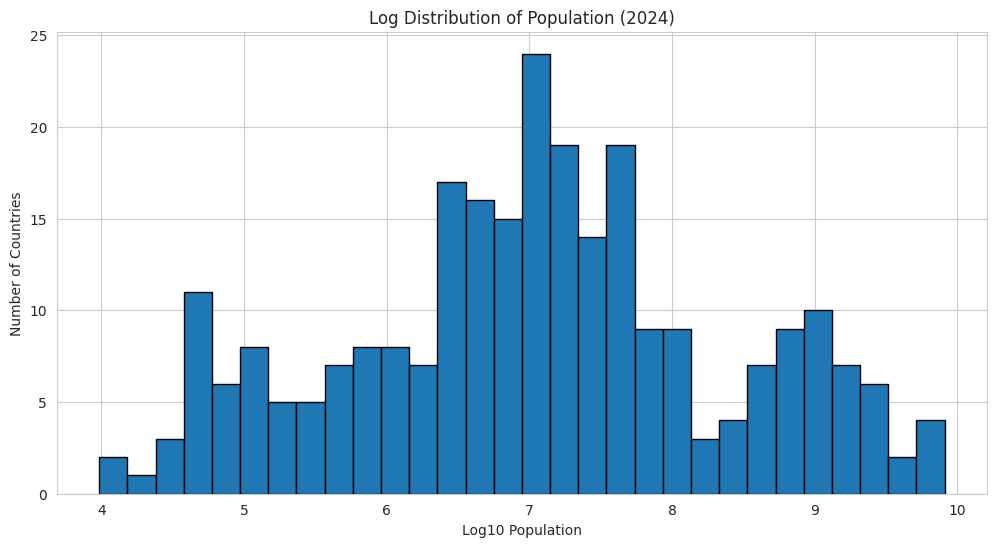

In [32]:
plt.figure(figsize=(12,6))

plt.hist(
    np.log10(population[latest_year]),
    bins=30,
    edgecolor='black'
)

plt.title(
    f'Log Distribution of Population ({latest_year})'
)

plt.xlabel('Log10 Population')
plt.ylabel('Number of Countries')

plt.show()

In [33]:
top10 = population.sort_values(
    by=latest_year,
    ascending=False
).head(10)

print(top10)

                   Country Name          2024
259                       World  8.141809e+09
103            IDA & IBRD total  6.926222e+09
140         Low & middle income  6.563502e+09
156               Middle income  5.938894e+09
102                   IBRD only  4.979422e+09
62   Early-demographic dividend  3.552279e+09
139         Lower middle income  3.120981e+09
249         Upper middle income  2.817913e+09
63          East Asia & Pacific  2.388319e+09
142   Late-demographic dividend  2.328628e+09


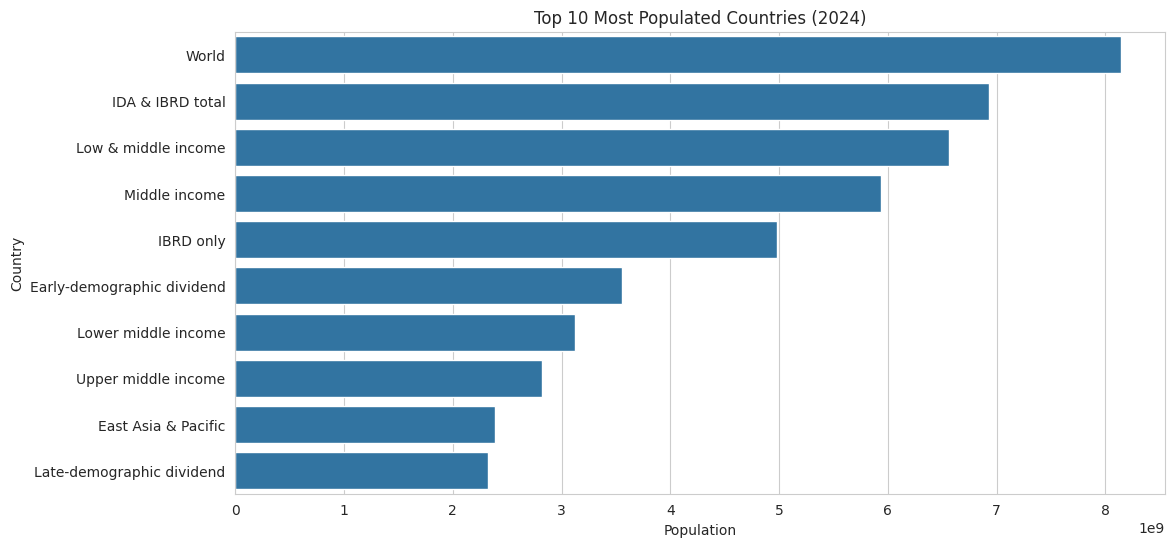

In [36]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x=latest_year,
    y='Country Name'
)

plt.title(
    f'Top 10 Most Populated Countries ({latest_year})'
)

plt.xlabel('Population')
plt.ylabel('Country')

plt.show()

In [37]:
plt.savefig(
    'histogram.png',
    dpi=300,
    bbox_inches='tight'
)

<Figure size 640x480 with 0 Axes>

In [38]:
plt.savefig(
    'top10_population.png',
    dpi=300,
    bbox_inches='tight'
)

<Figure size 640x480 with 0 Axes>